<a href="https://colab.research.google.com/github/givenn19/project/blob/deeplearning/WorkshopIncomplete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import os
import numpy as np
import random
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import kagglehub



In [ ]:

# =========================
# 2. SET PATHS & GET LABELS
# =========================

directory = kagglehub.dataset_download("lantian773030/pokemonclassification") + '/PokemonData'


labels = os.listdir(directory)  # Each subfolder is a Pokémon class
labels = [lbl for lbl in labels if os.path.isdir(os.path.join(directory, lbl))]
labels.sort()

# Trim the labels list to the subset you want to train on (lets start with 20 for now):
num_pokemon_to_classify = 20

labels = labels[:num_pokemon_to_classify]

num_classes = len(labels)

print(f"Found {num_classes} classes:")
print(labels)



Found 10 classes:
['Abra', 'Aerodactyl', 'Alakazam', 'Alolan Sandslash', 'Arbok', 'Arcanine', 'Articuno', 'Beedrill', 'Bellsprout', 'Blastoise']


In [ ]:
# =========================
# 3. LOAD IMAGES & LABELS
# =========================

def load_images_and_labels(root_dir, class_names):
    """
    Reads all images from subfolders (named by class), resizes them,
    normalizes pixel values, and returns (X, y).
    """
    data = []
    for idx, class_name in enumerate(class_names):
        class_folder = os.path.join(root_dir, class_name)

        for img_file in os.listdir(class_folder):
            img_path = os.path.join(class_folder, img_file)
            try:
                # Resize the image
                img = load_img(img_path, target_size=(???, ???))

                # Normalize the pixel values to be between 0 and 1
                img_array = img_to_array(img) / ???
                data.append((img_array, idx))
            except:
                # Skip corrupted or unreadable files
                pass

    random.shuffle(data)
    X, y = zip(*data)
    return np.array(X), np.array(y)

X, y = load_images_and_labels(directory, labels)
print(f"Total images loaded: {len(X)}")
print("X shape:", X.shape, "| y shape:", y.shape)

Total images loaded: 380
X shape: (380, 128, 128, 3) | y shape: (380,)


In [ ]:

# =========================
# 4. TRAIN/TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=????, random_state=42
)
print("Train set size:", len(X_train))
print("Test set size:", len(X_test))



Train set size: 304
Test set size: 76


In [ ]:

# =========================
# 5. DATA AUGMENTATION
# =========================
# A simple ImageDataGenerator for training data
train_datagen = ImageDataGenerator(
    rotation_range=??,
    width_shift_range=???,
    height_shift_range=???,
    brightness_range=???,
    shear_range=???,
    zoom_range=???,
    channel_shift_range=???,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode="nearest"
)
# What of these data augmentation methods should we keep, and which should be removed? What would be helpful to generalize the training data, and what would cause valuable data to be lost?

# For the test set, we usually do minimal or no augmentation
test_datagen = ImageDataGenerator()

# Fit the generators on the data
train_datagen.fit(?????)
test_datagen.fit(?????)

# Convert y to one-hot encoding
y_train_oh = tf.keras.utils.to_categorical(?????, num_classes=num_classes)
y_test_oh = tf.keras.utils.to_categorical(?????, num_classes=num_classes)



In [ ]:
# =========================
# 6. BUILD A SIMPLE CNN MODEL
# =========================
"""
In this section, we will build our convolutional neural network (CNN) model
using Keras. We'll use a Sequential model that stacks layers in order.

Below, you'll see many places marked with '???' that you will fill in.
The comments will guide you on what each parameter or function means.
"""

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    BatchNormalization
)

# 1. We choose the model type (Functional vs Sequential).
# 2. We add Convolutional layers + Batch Normalization + Pooling layers.
# 3. We Flatten the result, then add Dense layers.
# 4. We finish with an output layer of size 'num_classes' (softmax for multi-class).
# 5. Finally, we compile the model (choose optimizer, loss function, metrics).

# HINTS:
#  - 'filters' is how many feature detectors to learn in a Conv layer (e.g., 32, 64, 128).
#  - 'kernel_size' is the size of the sliding window (e.g., (3,3)).
#  - 'activation' is often 'relu' for convolution layers, 'softmax' for the last layer.
#  - 'input_shape' only needs to be specified in the first layer (height, width, channels).
#  - After Convolution, BatchNormalization can help stabilize and speed up training.
#  - MaxPooling2D((2,2)) halves the spatial dimensions of the feature maps.
#  - The final Dense layer must have 'num_classes' outputs for multi-class classification.

model = Sequential([
    # --- First Convolutional Block ---
    # Conv2D layer:
    # filters=??? : number of output feature maps (32? 64?).
    # kernel_size=(???, ???): e.g. (3,3).
    # activation='???': often 'relu'.
    # input_shape=(128, 128, 3): image size + 3 color channels.
    Conv2D(??? , (??? , ???), activation='???', input_shape=(??? , ??? , ???)),

    # Batch Normalization helps stabilize training
    BatchNormalization(),

    # Pooling layer to downsample
    MaxPooling2D((2,2)),

    # --- Second Convolutional Block ---
    Conv2D(??? , (??? , ???), activation='???'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # --- Third Convolutional Block ---
    Conv2D(??? , (??? , ???), activation='???'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # --- Flatten & Dense Layers ---
    # Flatten the 3D feature maps into a 1D vector
    Flatten(),

    # Fully-connected layer (Dense).
    # For example, 128 units + 'relu'
    Dense(??? , activation='???'),
    BatchNormalization(),

    # Final output layer: must match the number of classes (num_classes).
    # Use 'softmax' for multi-class classification.
    Dense(??? , activation='???')
])

# =========================
# 7. COMPILE THE MODEL
# =========================


model.compile(
    optimizer='???',
    loss='???',
    metrics=['accuracy']
)

# Show the model architecture
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# =========================
# 7. TRAIN THE MODEL
# =========================

batch_size = ??
epochs = ??

history = model.fit(
    train_datagen.flow(X_train, y_train_oh, batch_size=batch_size),
    validation_data=test_datagen.flow(X_test, y_test_oh, batch_size=batch_size),
    epochs=epochs
)



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 387ms/step - accuracy: 0.1415 - loss: 2.6338 - val_accuracy: 0.2368 - val_loss: 2.0367
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - accuracy: 0.3275 - loss: 1.9863 - val_accuracy: 0.2895 - val_loss: 1.7307
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - accuracy: 0.3150 - loss: 1.7778 - val_accuracy: 0.3816 - val_loss: 1.4646
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.4879 - loss: 1.4114 - val_accuracy: 0.6184 - val_loss: 1.4085
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.4514 - loss: 1.4056 - val_accuracy: 0.4605 - val_loss: 1.4213
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.4752 - loss: 1.3202 - val_accuracy: 0.5658 - val_loss: 1.0676
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.5316 - loss: 1.2085 - val_accuracy: 0.5658 - val_loss: 1.1518
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.5774 - loss: 1.1242 - val_accuracy: 0.

In [ ]:

# =========================
# 8. EVALUATE THE MODEL
# =========================
print("\nEvaluating on test set:")
test_loss, test_acc = model.evaluate(test_datagen.flow(X_test, y_test_oh, batch_size=batch_size))
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")




Evaluating on test set:
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7736 - loss: 0.6459
Test Loss: 0.6288
Test Accuracy: 0.7895


In [ ]:

# =========================
# 9. CLASSIFICATION REPORT
# =========================
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=labels))



3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Classification Report:
                  precision    recall  f1-score   support

            Abra       1.00      0.22      0.36         9
      Aerodactyl       1.00      0.75      0.86         8
        Alakazam       0.47      1.00      0.64         7
Alolan Sandslash       0.88      0.88      0.88         8
           Arbok       0.73      1.00      0.84         8
        Arcanine       0.88      0.88      0.88         8
        Articuno       0.83      0.83      0.83         6
        Beedrill       0.88      1.00      0.93         7
      Bellsprout       1.00      0.64      0.78        11
       Blastoise       0.80      1.00      0.89         4

        accuracy                           0.79        76
       macro avg       0.85      0.82      0.79        76
    weighted avg       0.86      0.79      0.78        76



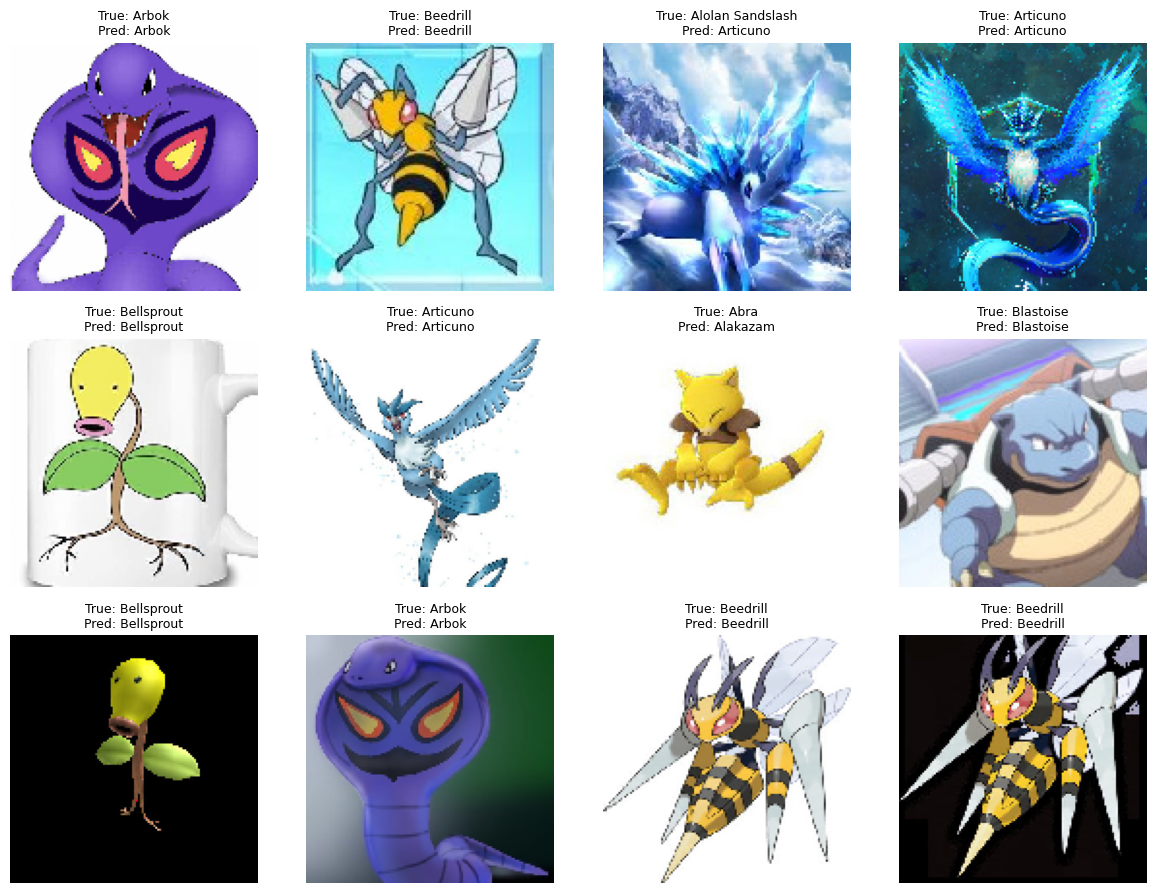

In [ ]:
# =========================
# 10. VISUALIZE SOME RESULTS
# =========================
def plot_samples(images, true_labels, pred_labels=None, n=12):
    """
    Plots a grid of sample images with their true and optionally predicted labels.
    """
    plt.figure(figsize=(12, 12))
    for i in range(n):
        plt.subplot(4, 4, i+1)
        plt.imshow(images[i])
        title_text = f"True: {labels[true_labels[i]]}"
        if pred_labels is not None:
            title_text += f"\nPred: {labels[pred_labels[i]]}"
        plt.title(title_text, fontsize=9)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Show some test images with predictions
plot_samples(X_test, y_test, y_pred, n=12)


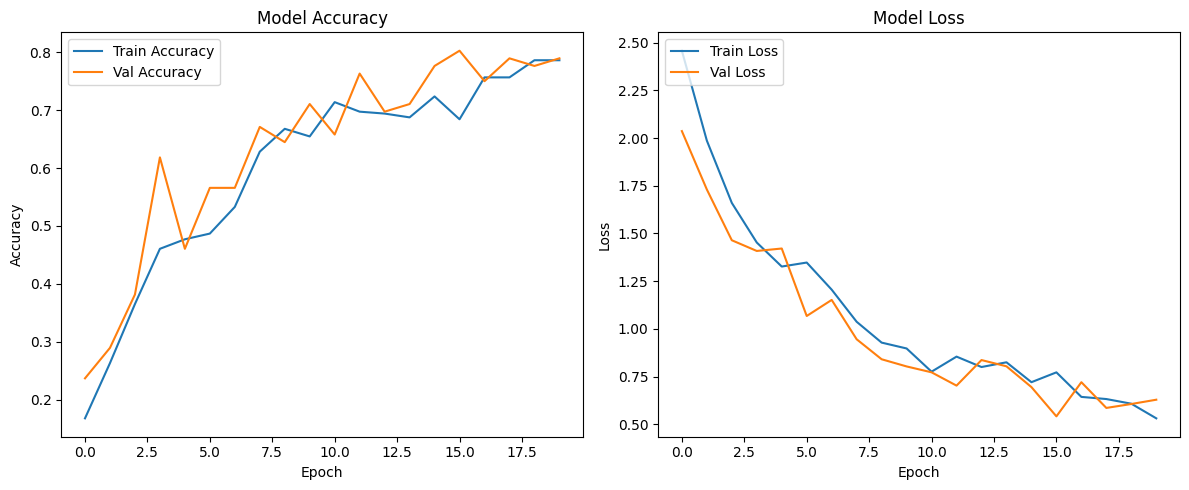

In [ ]:
# =========================
# 10. TRAINING GRAPHS
# =========================
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()